In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [5]:
np.random.seed(42)
n = 200

distance = np.random.uniform(1, 20, n)
duration = distance * np.random.uniform(2, 5, n)

time_of_day = np.random.choice(["Morning", "Afternoon", "Evening", "Night"], n)
traffic = np.random.choice(["Low", "Medium", "High"], n)
weather = np.random.choice(["Clear", "Rainy"], n)
demand = np.random.choice(["Low", "Medium", "High"], n)
day_type = np.random.choice(["Weekday", "Weekend"], n)

# Base price formula
price = (
    distance * 5 +
    duration * 0.5 +
    (traffic == "High") * 10 +
    (weather == "Rainy") * 8 +
    (demand == "High") * 15 +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "distance_km": distance,
    "duration_min": duration,
    "time_of_day": time_of_day,
    "traffic_level": traffic,
    "weather": weather,
    "demand_level": demand,
    "day_type": day_type,
    "ride_price": price
})

df.to_csv("rides.csv", index=False)


In [6]:
#Data Exploration
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance_km    200 non-null    float64
 1   duration_min   200 non-null    float64
 2   time_of_day    200 non-null    object 
 3   traffic_level  200 non-null    object 
 4   weather        200 non-null    object 
 5   demand_level   200 non-null    object 
 6   day_type       200 non-null    object 
 7   ride_price     200 non-null    float64
dtypes: float64(3), object(5)
memory usage: 12.6+ KB


distance_km      0
duration_min     0
time_of_day      0
traffic_level    0
weather          0
demand_level     0
day_type         0
ride_price       0
dtype: int64

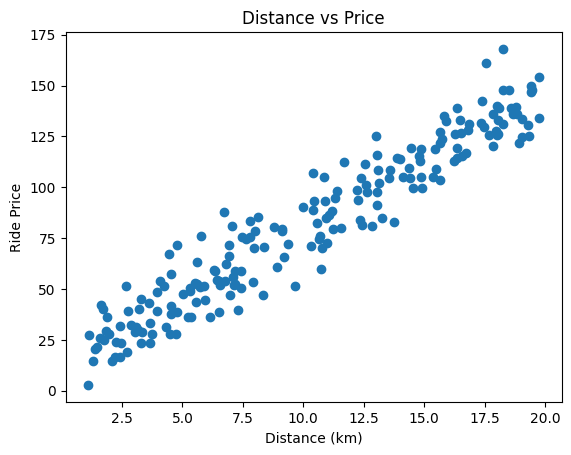

In [7]:
#Visualization

plt.scatter(df["distance_km"], df["ride_price"])
plt.xlabel("Distance (km)")
plt.ylabel("Ride Price")
plt.title("Distance vs Price")
plt.show()


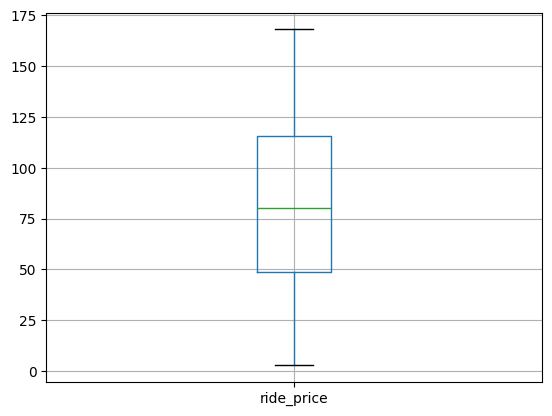

In [8]:
df.boxplot(column="ride_price")
plt.show()


In [9]:
#Data Cleaning & Feature Engineering
#️ Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)
#Encode Categorical Variables
df_encoded = pd.get_dummies(df, drop_first=True)


In [10]:
#Scale Numerical Features

scaler = StandardScaler()

num_cols = ["distance_km", "duration_min"]

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


In [18]:

X = df_encoded.drop("ride_price", axis=1)
y = df_encoded["ride_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#Regression Model (Linear Regression)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


MAE: 4.115167012272336
R2 Score: 0.98493293034741


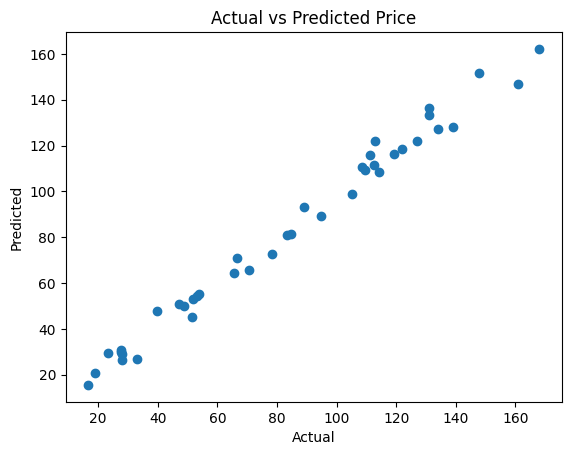

In [13]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Price")
plt.show()


In [14]:
#Classification Model
  #Create high_cost variable
df_encoded["high_cost"] = (df_encoded["ride_price"] > df_encoded["ride_price"].median()).astype(int)
#Split again
X = df_encoded.drop(["ride_price", "high_cost"], axis=1)
y = df_encoded["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
#Train Logistic Regression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


Accuracy: 0.95
Confusion Matrix:
 [[19  0]
 [ 2 19]]


In [16]:
#Model Comparison Discussion

#-Regression predicts exact price

#-Classification predicts price category

#-Regression sensitive to outliers

#-Classification depends on threshold

In [17]:
#Ethical Reflection

    #-Potential unfair behavior:

#High demand areas may always have higher prices → may disadvantage low-income neighborhoods.

    #-Real-world risk:

#Model may learn biased pricing patterns from historical data.

     #-Dataset limitation:

#Synthetic dataset does not include real-world driver behavior or fuel cost.